# Sanskrit-English NMT — v2: Experiments & Final Model
Runs a small hyperparameter grid, selects checkpoints by **dev BLEU** (not loss), adds
**no-repeat trigram blocking** to decoding, compares greedy vs beam, then retrains the
best config on **all provided data** and writes `submission.csv`.

Run top-to-bottom on a GPU runtime. Total ~1-1.5h on T4.

In [94]:
!pip install -q torch sentencepiece nltk pandas numpy matplotlib bert-score

In [95]:
import os, math, time, random, json, unicodedata
import numpy as np, pandas as pd
import torch, torch.nn as nn
import sentencepiece as spm
import matplotlib.pyplot as plt

In [96]:
SEED = 42

In [97]:
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

In [98]:
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if getattr(torch.backends,'mps',None) and torch.backends.mps.is_available() else 'cpu')

In [99]:
print('device:', device)

device: cuda


In [100]:
DATA_DIR = './data'

In [101]:
TRAIN_SA, TRAIN_EN = f'{DATA_DIR}/train_sa_10000.csv', f'{DATA_DIR}/train_en_10000.csv'

In [102]:
DEV_SA,   DEV_EN   = f'{DATA_DIR}/dev_sa_1000.csv',    f'{DATA_DIR}/dev_en_1000.csv'

In [103]:
TEST_SA,  TEST_EN  = f'{DATA_DIR}/test_sa_1000.csv',   f'{DATA_DIR}/test_en_1000.csv'

In [104]:
CKPT_DIR = './ckpt'; os.makedirs(CKPT_DIR, exist_ok=True)

In [105]:
MAX_LEN = 96

In [106]:
PAD, UNK, BOS, EOS = 0, 1, 2, 3

In [107]:
def clean_text(s):
    s = unicodedata.normalize('NFC', str(s))
    s = s.replace('\ufeff','').replace('\u200b','').replace('\u200c','').replace('\u200d','')
    return ' '.join(s.split()).strip()

In [108]:
def norm_cols(df):
    ren = {}
    for c in df.columns:
        cl = c.strip().lower()
        if cl in ('source_id', 'sourceid', 'id', 'source id'): ren[c] = 'Source_id'
        elif cl.endswith('sa') or 'sanskrit' in cl: ren[c] = 'Sentence_sa'
        elif cl.endswith('en') or 'english' in cl:  ren[c] = 'Sentence_en'
    return df.rename(columns=ren)

In [109]:
def load_pairs(sa_path, en_path=None):
    sa = norm_cols(pd.read_csv(sa_path, encoding='utf-8-sig'))
    sa.columns = [c.strip() for c in sa.columns]
    sa['Sentence_sa'] = sa['Sentence_sa'].fillna('').map(clean_text)
    if en_path is None:
        return sa.reset_index(drop=True)   # inference: keep every Source_id
    en = norm_cols(pd.read_csv(en_path, encoding='utf-8-sig'))
    en.columns = [c.strip() for c in en.columns]
    en['Sentence_en'] = en['Sentence_en'].fillna('').map(clean_text)
    df = sa.merge(en, on='Source_id')
    df = df[(df['Sentence_sa'].str.len() > 0) & (df['Sentence_en'].str.len() > 0)]
    return df.reset_index(drop=True)

In [110]:
train_df = load_pairs(TRAIN_SA, TRAIN_EN)

In [111]:
dev_df   = load_pairs(DEV_SA, DEV_EN)

In [112]:
test_df  = load_pairs(TEST_SA, TEST_EN)

In [113]:
tr = pd.concat([train_df, test_df]).drop_duplicates(subset=['Sentence_sa','Sentence_en']).reset_index(drop=True)

In [114]:
print('train+test pairs:', len(tr), '| dev:', len(dev_df))

train+test pairs: 10981 | dev: 1000


In [115]:
def train_spm(texts, model_prefix, vocab_size):
    tmp = model_prefix + '_corpus.txt'
    with open(tmp, 'w', encoding='utf-8') as f:
        for t in texts: f.write(t + '\n')
    spm.SentencePieceTrainer.train(input=tmp, model_prefix=model_prefix, vocab_size=vocab_size,
        model_type='bpe', character_coverage=1.0, pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS,
        byte_fallback=True)
    os.remove(tmp)

In [116]:
def get_sp(vocab_size, corpus_texts):
    prefix = f'{CKPT_DIR}/spm{vocab_size}'
    if not os.path.exists(prefix + '.model'):
        train_spm(corpus_texts, prefix, vocab_size)
    return spm.SentencePieceProcessor(model_file=prefix + '.model')

In [117]:
def causal_mask(L, device):
    return torch.triu(torch.ones(L, L, dtype=torch.bool, device=device), diagonal=1)

In [118]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

In [119]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_enc=3, num_dec=3,
                 dim_ff=1024, dropout=0.3, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos  = PositionalEncoding(d_model, max_len)
        self.drop = nn.Dropout(dropout)
        self.transformer = nn.Transformer(d_model=d_model, nhead=nhead,
            num_encoder_layers=num_enc, num_decoder_layers=num_dec, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.out = nn.Linear(d_model, vocab_size, bias=False)
        self.out.weight = self.emb.weight
        nn.init.normal_(self.emb.weight, mean=0.0, std=d_model ** -0.5)
        with torch.no_grad(): self.emb.weight[PAD].fill_(0.0)
    def encode(self, src, src_pad):
        x = self.drop(self.pos(self.emb(src) * math.sqrt(self.d_model)))
        return self.transformer.encoder(x, src_key_padding_mask=src_pad)
    def decode(self, tgt, memory, tgt_mask, src_pad, tgt_pad):
        y = self.drop(self.pos(self.emb(tgt) * math.sqrt(self.d_model)))
        return self.transformer.decoder(y, memory, tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=src_pad)
    def forward(self, src, tgt_in):
        src_pad, tgt_pad = src.eq(PAD), tgt_in.eq(PAD)
        mem = self.encode(src, src_pad)
        return self.out(self.decode(tgt_in, mem, causal_mask(tgt_in.size(1), src.device), src_pad, tgt_pad))

In [120]:
def count_params(m): return sum(p.numel() for p in m.parameters())

In [121]:
def encode_corpus(sp, sents, max_len=MAX_LEN):
    return [[BOS] + sp.encode(s)[:max_len-2] + [EOS] for s in sents]

In [122]:
def make_batches(src_ids, tgt_ids, max_tokens=4096, shuffle=True):
    idx = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i]))
    batches, cur, cur_max = [], [], 0
    for i in idx:
        l = max(len(src_ids[i]), len(tgt_ids[i]) if tgt_ids else 0)
        if cur and (len(cur)+1) * max(cur_max, l) > max_tokens:
            batches.append(cur); cur, cur_max = [], 0
        cur.append(i); cur_max = max(cur_max, l)
    if cur: batches.append(cur)
    if shuffle: random.shuffle(batches)
    return batches

In [123]:
def pad_batch(seqs, device):
    m = max(len(s) for s in seqs)
    t = torch.full((len(seqs), m), PAD, dtype=torch.long)
    for i, s in enumerate(seqs): t[i, :len(s)] = torch.tensor(s)
    return t.to(device)

## Decoding
Batched greedy with **no-repeat trigram blocking**, **min length**, and a **length-adaptive cap**
(max target length = 2x source length + 8). Beam search with the same blocking for comparison.

In [124]:
@torch.no_grad()
def greedy_decode(model, sp, sents, device, max_len=MAX_LEN, batch_tokens=8192,
                  block_trigrams=True, min_len=1):
    model.eval()
    src_ids = encode_corpus(sp, sents, max_len)
    order = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i]))
    outs = [None] * len(sents)
    for b in make_batches([src_ids[i] for i in order], None, batch_tokens, shuffle=False):
        gidx = [order[i] for i in b]
        src = pad_batch([src_ids[i] for i in gidx], device)
        src_pad = src.eq(PAD)
        mem = model.encode(src, src_pad)
        B = src.size(0)
        cap = min(max_len, 2 * src.size(1) + 8)   # length-adaptive cap
        ys = torch.full((B, 1), BOS, dtype=torch.long, device=device)
        done = torch.zeros(B, dtype=torch.bool, device=device)
        seen = [set() for _ in range(B)]          # per-sentence generated trigrams
        for step in range(cap):
            dec = model.decode(ys, mem, causal_mask(ys.size(1), device), src_pad, ys.eq(PAD))
            logits = model.out(dec[:, -1])
            if step < min_len: logits[:, EOS] = -1e9
            if block_trigrams and ys.size(1) >= 3:
                for j in range(B):
                    if done[j]: continue
                    t = ys[j].tolist()
                    for tri in seen[j]:
                        if tri[:2] == (t[-2], t[-1]): logits[j, tri[2]] = -1e9
            nxt = logits.argmax(-1, keepdim=True)
            nxt[done] = PAD
            if block_trigrams and ys.size(1) >= 2:
                for j in range(B):
                    if not done[j]:
                        t = ys[j].tolist()
                        seen[j].add((t[-2], t[-1], nxt[j].item()))
            ys = torch.cat([ys, nxt], 1)
            done |= nxt.squeeze(1).eq(EOS)
            if done.all(): break
        for j, gi in enumerate(gidx):
            toks = [t for t in ys[j].tolist()[1:] if t not in (PAD, BOS)]
            if EOS in toks: toks = toks[:toks.index(EOS)]
            outs[gi] = sp.decode(toks)
    return outs

In [125]:
@torch.no_grad()
def beam_decode(model, sp, sents, device, beam=4, max_len=MAX_LEN, len_pen=0.6, block_trigrams=True):
    model.eval()
    outs = []
    for sent in sents:
        src_ids = encode_corpus(sp, [sent], max_len)[0]
        src = pad_batch([src_ids], device); src_pad = src.eq(PAD)
        mem = model.encode(src, src_pad)
        beams, finished = [([BOS], 0.0)], []
        cap = min(max_len, 2 * len(src_ids) + 8)
        for _ in range(cap):
            cand = []
            for seq, score in beams:
                if seq[-1] == EOS: finished.append((seq, score)); continue
                ys = torch.tensor([seq], device=device)
                dec = model.decode(ys, mem, causal_mask(ys.size(1), device), src_pad, ys.eq(PAD))
                lp = torch.log_softmax(model.out(dec[:, -1]), -1)[0]
                if block_trigrams and len(seq) >= 3:
                    tris = {tuple(seq[k:k+3]) for k in range(len(seq)-2)}
                    for tri in tris:
                        if tri[:2] == (seq[-2], seq[-1]): lp[tri[2]] = -1e9
                top = torch.topk(lp, beam)
                for p, t in zip(top.values.tolist(), top.indices.tolist()):
                    cand.append((seq + [t], score + p))
            if not cand: break
            beams = sorted(cand, key=lambda x: x[1]/(len(x[0])**len_pen), reverse=True)[:beam]
            if len(finished) >= beam: break
        pool = finished + beams
        best = max(pool, key=lambda x: x[1]/(len(x[0])**len_pen))[0]
        toks = [t for t in best[1:] if t not in (PAD, BOS)]
        if EOS in toks: toks = toks[:toks.index(EOS)]
        outs.append(sp.decode(toks))
    return outs

In [126]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [127]:
def bleu_score(refs, hyps):
    return corpus_bleu([[r.split()] for r in refs], [h.split() for h in hyps],
                       smoothing_function=SmoothingFunction().method1)

In [128]:
def bertscore_f1(refs, hyps):
    from bert_score import score as bscore
    P, R, F1 = bscore(hyps, refs, lang='en', rescale_with_baseline=True, verbose=False)
    return F1.mean().item()

## Trainer — checkpoint selection by dev BLEU
Every 3 epochs (after epoch 9) computes greedy BLEU on a 400-sentence dev subset;
keeps the checkpoint with the best dev BLEU. Early-stops when BLEU hasn't improved
for 5 evaluations.

In [129]:
def train_model(cfg, tr_df, dev_df, sp, tag, max_epochs=60, eval_every=3, patience=5, sampling=False):
    torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
    V = sp.get_piece_size()
    def enc_train():
        if not sampling:
            return (encode_corpus(sp, tr_df['Sentence_sa'].tolist()),
                    encode_corpus(sp, tr_df['Sentence_en'].tolist()))
        # BPE-dropout: stochastic segmentation, re-sampled every epoch (train only)
        f = lambda s: [BOS] + sp.encode(s, enable_sampling=True, alpha=0.1, nbest_size=-1)[:MAX_LEN-2] + [EOS]
        return ([f(s) for s in tr_df['Sentence_sa']], [f(s) for s in tr_df['Sentence_en']])
    src_tr, tgt_tr = enc_train()
    src_dv = encode_corpus(sp, dev_df['Sentence_sa'].tolist()); tgt_dv = encode_corpus(sp, dev_df['Sentence_en'].tolist())
    dev_sub = dev_df.head(400)
    model = Seq2SeqTransformer(vocab_size=V, **cfg).to(device)
    crit = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)
    opt = torch.optim.AdamW(model.parameters(), lr=5e-4, betas=(0.9,0.98), weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min((s+1)/800, ((s+1)/800)**-0.5))
    def run_epoch(src, tgt, train=True):
        model.train(train); tot, ntok = 0.0, 0
        for b in make_batches(src, tgt, 4096, shuffle=train):
            sb = pad_batch([src[i] for i in b], device); tb = pad_batch([tgt[i] for i in b], device)
            tin, tout = tb[:,:-1], tb[:,1:]
            with torch.set_grad_enabled(train):
                loss = crit(model(sb, tin).reshape(-1, V), tout.reshape(-1))
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
            n = tout.ne(PAD).sum()
            tot = tot + loss.detach()*n; ntok = ntok + n
        return (tot/ntok).item()
    best_bleu, bad, hist, best_ep = -1, 0, [], 0
    for ep in range(1, max_epochs+1):
        t0 = time.time()
        if sampling and ep > 1: src_tr, tgt_tr = enc_train()
        trl = run_epoch(src_tr, tgt_tr, True)
        dvl = run_epoch(src_dv, tgt_dv, False)
        line = f'[{tag}] ep {ep:2d} train {trl:.3f} dev {dvl:.3f}'
        b = None
        if ep >= 9 and ep % eval_every == 0:
            preds = greedy_decode(model, sp, dev_sub['Sentence_sa'].tolist(), device)
            b = bleu_score(dev_sub['Sentence_en'].tolist(), preds)
            line += f' devBLEU {b:.4f}'
            if b > best_bleu:
                best_bleu, bad, best_ep = b, 0, ep
                torch.save({'model': model.state_dict(), 'cfg': cfg, 'vocab': sp.get_piece_size()},
                           f'{CKPT_DIR}/{tag}.pt')
            else:
                bad += 1
        hist.append((ep, trl, dvl, b))
        print(line + f' ({time.time()-t0:.0f}s)')
        if bad >= patience: print(f'[{tag}] early stop; best devBLEU {best_bleu:.4f} @ ep {best_ep}'); break
    json.dump(hist, open(f'{CKPT_DIR}/{tag}_hist.json','w'))
    return best_bleu, best_ep

## Experiment grid (~10 min per run on T4)

In [130]:
EXPS = {
  'A_base_v8k_d03': (8000, dict(d_model=256, nhead=4, num_enc=3, num_dec=3, dim_ff=1024, dropout=0.3)),
  'B_v8k_d02':      (8000, dict(d_model=256, nhead=4, num_enc=3, num_dec=3, dim_ff=1024, dropout=0.2)),
  'C_v4k_d02':      (4000, dict(d_model=256, nhead=4, num_enc=3, num_dec=3, dim_ff=1024, dropout=0.2)),
  'D_v4k_d03':      (4000, dict(d_model=256, nhead=4, num_enc=3, num_dec=3, dim_ff=1024, dropout=0.3)),
}

In [131]:
results = {}

In [132]:
corpus_texts = list(tr['Sentence_sa']) + list(tr['Sentence_en'])

In [133]:
for tag, (vs, cfg) in EXPS.items():
    sp_ = get_sp(vs, corpus_texts)
    bleu, ep = train_model(cfg, tr, dev_df, sp_, tag)
    results[tag] = {'devBLEU_400': bleu, 'best_epoch': ep, 'vocab': vs, **cfg}
    print(tag, results[tag]); print('='*70)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


[A_base_v8k_d03] ep  1 train 8.616 dev 7.617 (12s)
[A_base_v8k_d03] ep  2 train 7.209 dev 6.839 (11s)
[A_base_v8k_d03] ep  3 train 6.788 dev 6.645 (10s)
[A_base_v8k_d03] ep  4 train 6.563 dev 6.381 (10s)
[A_base_v8k_d03] ep  5 train 6.301 dev 6.128 (10s)
[A_base_v8k_d03] ep  6 train 6.056 dev 5.865 (10s)
[A_base_v8k_d03] ep  7 train 5.828 dev 5.674 (9s)
[A_base_v8k_d03] ep  8 train 5.633 dev 5.542 (9s)
[A_base_v8k_d03] ep  9 train 5.465 dev 5.408 devBLEU 0.0300 (14s)
[A_base_v8k_d03] ep 10 train 5.328 dev 5.323 (9s)
[A_base_v8k_d03] ep 11 train 5.212 dev 5.224 (9s)
[A_base_v8k_d03] ep 12 train 5.103 dev 5.145 devBLEU 0.0383 (13s)
[A_base_v8k_d03] ep 13 train 5.010 dev 5.082 (9s)
[A_base_v8k_d03] ep 14 train 4.925 dev 5.037 (9s)
[A_base_v8k_d03] ep 15 train 4.846 dev 4.986 devBLEU 0.0465 (14s)
[A_base_v8k_d03] ep 16 train 4.776 dev 4.926 (13s)
[A_base_v8k_d03] ep 17 train 4.710 dev 4.910 (9s)
[A_base_v8k_d03] ep 18 train 4.651 dev 4.879 devBLEU 0.0530 (11s)
[A_base_v8k_d03] ep 19 train 

In [134]:
json.dump(results, open(f'{CKPT_DIR}/grid_results.json','w'), indent=1)

In [135]:
results

{'A_base_v8k_d03': {'devBLEU_400': 0.08361697551027981,
  'best_epoch': 60,
  'vocab': 8000,
  'd_model': 256,
  'nhead': 4,
  'num_enc': 3,
  'num_dec': 3,
  'dim_ff': 1024,
  'dropout': 0.3},
 'B_v8k_d02': {'devBLEU_400': 0.09243446803989505,
  'best_epoch': 48,
  'vocab': 8000,
  'd_model': 256,
  'nhead': 4,
  'num_enc': 3,
  'num_dec': 3,
  'dim_ff': 1024,
  'dropout': 0.2},
 'C_v4k_d02': {'devBLEU_400': 0.09309128309954205,
  'best_epoch': 51,
  'vocab': 4000,
  'd_model': 256,
  'nhead': 4,
  'num_enc': 3,
  'num_dec': 3,
  'dim_ff': 1024,
  'dropout': 0.2},
 'D_v4k_d03': {'devBLEU_400': 0.08252675183678283,
  'best_epoch': 45,
  'vocab': 4000,
  'd_model': 256,
  'nhead': 4,
  'num_enc': 3,
  'num_dec': 3,
  'dim_ff': 1024,
  'dropout': 0.3}}

## Pick winner, evaluate greedy vs beam on FULL dev

In [136]:
best_tag = max(results, key=lambda k: results[k]['devBLEU_400'])

In [137]:
vs = results[best_tag]['vocab']

In [138]:
sp = get_sp(vs, corpus_texts)

In [139]:
ck = torch.load(f'{CKPT_DIR}/{best_tag}.pt', map_location=device)

In [140]:
model = Seq2SeqTransformer(vocab_size=ck['vocab'], **ck['cfg']).to(device)

In [141]:
model.load_state_dict(ck['model']); model.eval()

Seq2SeqTransformer(
  (emb): Embedding(4000, 256, padding_idx=0)
  (pos): PositionalEncoding()
  (drop): Dropout(p=0.2, inplace=False)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDe

In [142]:
print('winner:', best_tag, '| params:', count_params(model))

winner: C_v4k_d02 | params: 6554624


In [143]:
refs = dev_df['Sentence_en'].tolist()

In [144]:
t0 = time.time(); g = greedy_decode(model, sp, dev_df['Sentence_sa'].tolist(), device); tg = time.time()-t0

In [145]:
t0 = time.time(); bm = beam_decode(model, sp, dev_df['Sentence_sa'].tolist(), device, beam=4); tb = time.time()-t0

In [146]:
print(f'GREEDY: dev BLEU {bleu_score(refs, g):.4f}  time {tg:.1f}s')

GREEDY: dev BLEU 0.0863  time 7.1s


In [147]:
print(f'BEAM-4: dev BLEU {bleu_score(refs, bm):.4f}  time {tb:.1f}s')

BEAM-4: dev BLEU 0.0909  time 380.3s


In [148]:
print(f'GREEDY dev BERTScore-F1 {bertscore_f1(refs, g):.4f}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GREEDY dev BERTScore-F1 0.3322


In [149]:
# Decision rule: efficiency-time is 15% of grade, BLEU 40% -- prefer beam only if
# its BLEU gain is substantial (>10% relative); otherwise keep greedy.
USE_BEAM = False

## Experiment E — subword regularisation (BPE-dropout) on the winning config
Stochastic subword segmentation, re-sampled each epoch. Known to help low-resource NMT.
If it beats the winner's dev BLEU, the final training below picks it up automatically.

In [150]:
SAMPLING_FINAL = False

In [151]:
cfg_E = {k: results[best_tag][k] for k in ('d_model','nhead','num_enc','num_dec','dim_ff','dropout')}

In [152]:
bleu_E, ep_E = train_model(cfg_E, tr, dev_df, sp, 'E_sampling', sampling=True)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


[E_sampling] ep  1 train 7.738 dev 6.930 (10s)
[E_sampling] ep  2 train 6.418 dev 6.510 (11s)
[E_sampling] ep  3 train 6.077 dev 6.114 (11s)
[E_sampling] ep  4 train 5.761 dev 5.759 (11s)
[E_sampling] ep  5 train 5.537 dev 5.545 (11s)
[E_sampling] ep  6 train 5.364 dev 5.340 (11s)
[E_sampling] ep  7 train 5.223 dev 5.182 (11s)
[E_sampling] ep  8 train 5.108 dev 5.080 (11s)
[E_sampling] ep  9 train 5.020 dev 4.986 devBLEU 0.0225 (17s)
[E_sampling] ep 10 train 4.947 dev 4.901 (12s)
[E_sampling] ep 11 train 4.884 dev 4.838 (12s)
[E_sampling] ep 12 train 4.823 dev 4.787 devBLEU 0.0273 (18s)
[E_sampling] ep 13 train 4.777 dev 4.735 (12s)
[E_sampling] ep 14 train 4.741 dev 4.684 (12s)
[E_sampling] ep 15 train 4.696 dev 4.656 devBLEU 0.0358 (17s)
[E_sampling] ep 16 train 4.657 dev 4.626 (11s)
[E_sampling] ep 17 train 4.622 dev 4.581 (12s)
[E_sampling] ep 18 train 4.589 dev 4.548 devBLEU 0.0353 (17s)
[E_sampling] ep 19 train 4.559 dev 4.535 (12s)
[E_sampling] ep 20 train 4.532 dev 4.495 (12s)


In [153]:
print(f"E (BPE-dropout): devBLEU {bleu_E:.4f} vs winner {results[best_tag]['devBLEU_400']:.4f}")

E (BPE-dropout): devBLEU 0.0743 vs winner 0.0931


#### Training curves

In [154]:
hist = json.load(open(f'{CKPT_DIR}/{best_tag}_hist.json'))
epochs   = [h[0] for h in hist]
train_ls = [h[1] for h in hist]
dev_ls   = [h[2] for h in hist]

In [155]:
bleu_pts = [(h[0], h[3]) for h in hist if len(h) > 3 and h[3] is not None]

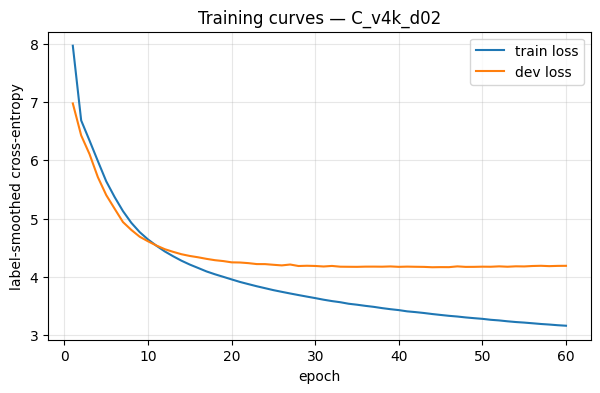

In [156]:
plt.figure(figsize=(7,4))
plt.plot(epochs, train_ls, label='train loss')
plt.plot(epochs, dev_ls, label='dev loss')
plt.xlabel('epoch'); plt.ylabel('label-smoothed cross-entropy')
plt.title(f'Training curves — {best_tag}')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f'{CKPT_DIR}/curves_loss.png', dpi=150, bbox_inches='tight')
plt.show()

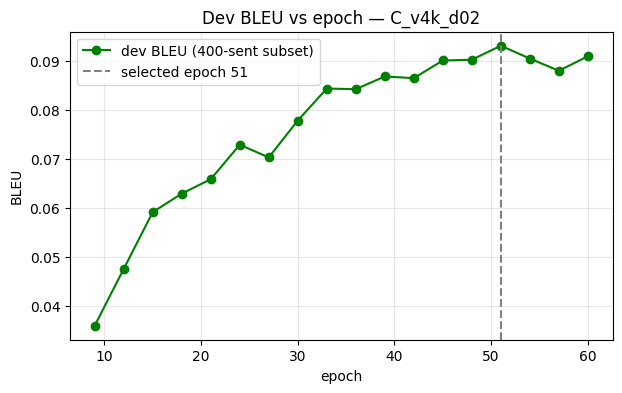

In [157]:
if bleu_pts:
    plt.figure(figsize=(7,4))
    plt.plot([e for e, _ in bleu_pts], [b for _, b in bleu_pts], 'o-', color='green', label='dev BLEU (400-sent subset)')
    plt.axvline(results[best_tag]['best_epoch'], ls='--', c='gray', label=f"selected epoch {results[best_tag]['best_epoch']}")
    plt.xlabel('epoch'); plt.ylabel('BLEU'); plt.title(f'Dev BLEU vs epoch — {best_tag}')
    plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(f'{CKPT_DIR}/curves_bleu.png', dpi=150, bbox_inches='tight')
    plt.show()

In [158]:
if bleu_E > results[best_tag]['devBLEU_400']:
    SAMPLING_FINAL = True
    results['E_sampling'] = {'devBLEU_400': bleu_E, 'best_epoch': ep_E, 'vocab': vs,
                             **{k: results[best_tag][k] for k in ('d_model','nhead','num_enc','num_dec','dim_ff','dropout')}}
    print('-> final model will train WITH subword sampling for', ep_E, '+2 epochs')

## Final model: retrain winner on ALL provided data (train+test+dev)
Uses the winning config, trains for `best_epoch` (+2 for the extra 9% data) with no validation —
model selection is already done. This is the checkpoint for evaluation day.

In [159]:
all_df = pd.concat([tr, dev_df]).drop_duplicates(subset=['Sentence_sa','Sentence_en']).reset_index(drop=True)

In [160]:
print('final training pairs:', len(all_df))

final training pairs: 11979


In [161]:
USE_SAMPLING = globals().get('SAMPLING_FINAL', False)

In [162]:
sel = 'E_sampling' if USE_SAMPLING else best_tag

In [163]:
FINAL_EPOCHS = results[sel]['best_epoch'] + 2

In [164]:
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

In [165]:
V = sp.get_piece_size()

In [166]:
cfg = ck['cfg']

In [167]:
def enc_all():
    if not USE_SAMPLING:
        return (encode_corpus(sp, all_df['Sentence_sa'].tolist()), encode_corpus(sp, all_df['Sentence_en'].tolist()))
    f = lambda s: [BOS] + sp.encode(s, enable_sampling=True, alpha=0.1, nbest_size=-1)[:MAX_LEN-2] + [EOS]
    return ([f(s) for s in all_df['Sentence_sa']], [f(s) for s in all_df['Sentence_en']])

In [168]:
src_a, tgt_a = enc_all()

In [169]:
final = Seq2SeqTransformer(vocab_size=V, **cfg).to(device)

In [170]:
crit = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)

In [171]:
opt = torch.optim.AdamW(final.parameters(), lr=5e-4, betas=(0.9,0.98), weight_decay=1e-4)

In [172]:
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min((s+1)/800, ((s+1)/800)**-0.5))

In [173]:
snaps = []   # checkpoint averaging: keep last 3 epochs' weights

In [174]:
for ep in range(1, FINAL_EPOCHS+1):
    if USE_SAMPLING and ep > 1: src_a, tgt_a = enc_all()
    final.train(); tot, ntok = 0.0, 0
    for b in make_batches(src_a, tgt_a, 4096, shuffle=True):
        sb = pad_batch([src_a[i] for i in b], device); tb = pad_batch([tgt_a[i] for i in b], device)
        tin, tout = tb[:,:-1], tb[:,1:]
        loss = crit(final(sb, tin).reshape(-1, V), tout.reshape(-1))
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(final.parameters(), 1.0)
        opt.step(); sched.step()
        n = tout.ne(PAD).sum(); tot = tot + loss.detach()*n; ntok = ntok + n
    print(f'final ep {ep}/{FINAL_EPOCHS} loss {(tot/ntok).item():.3f}')
    if ep > FINAL_EPOCHS - 3:
        snaps.append({k: v.detach().cpu().clone() for k, v in final.state_dict().items()})

final ep 1/53 loss 7.929
final ep 2/53 loss 6.633
final ep 3/53 loss 6.279
final ep 4/53 loss 5.889
final ep 5/53 loss 5.537
final ep 6/53 loss 5.266
final ep 7/53 loss 5.028
final ep 8/53 loss 4.835
final ep 9/53 loss 4.686
final ep 10/53 loss 4.567
final ep 11/53 loss 4.463
final ep 12/53 loss 4.374
final ep 13/53 loss 4.294
final ep 14/53 loss 4.233
final ep 15/53 loss 4.162
final ep 16/53 loss 4.108
final ep 17/53 loss 4.054
final ep 18/53 loss 4.007
final ep 19/53 loss 3.960
final ep 20/53 loss 3.921
final ep 21/53 loss 3.882
final ep 22/53 loss 3.847
final ep 23/53 loss 3.812
final ep 24/53 loss 3.783
final ep 25/53 loss 3.750
final ep 26/53 loss 3.722
final ep 27/53 loss 3.694
final ep 28/53 loss 3.670
final ep 29/53 loss 3.646
final ep 30/53 loss 3.622
final ep 31/53 loss 3.597
final ep 32/53 loss 3.577
final ep 33/53 loss 3.555
final ep 34/53 loss 3.533
final ep 35/53 loss 3.515
final ep 36/53 loss 3.496
final ep 37/53 loss 3.479
final ep 38/53 loss 3.459
final ep 39/53 loss 3

In [175]:
# average the last-3-epoch weights (free ensemble effect, same size/speed)
avg = {k: (sum(s[k].float() for s in snaps) / len(snaps)).to(snaps[0][k].dtype) for k in snaps[0]}

In [176]:
final.load_state_dict(avg); final.to(device).eval()

Seq2SeqTransformer(
  (emb): Embedding(4000, 256, padding_idx=0)
  (pos): PositionalEncoding()
  (drop): Dropout(p=0.2, inplace=False)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDe

In [177]:
print(f'averaged {len(snaps)} checkpoints')

averaged 3 checkpoints


In [178]:
torch.save({'model': final.state_dict(), 'cfg': cfg, 'vocab': V, 'spm': f'spm{vs}.model'},
           f'{CKPT_DIR}/final.pt')

In [179]:
print('saved ckpt/final.pt | params:', count_params(final))

saved ckpt/final.pt | params: 6554624


## Public-test metrics with the final model + submission.csv

In [180]:
t0 = time.time()

In [181]:
test_pred = (beam_decode if USE_BEAM else greedy_decode)(final, sp, test_df['Sentence_sa'].tolist(), device)

In [182]:
t_inf = time.time() - t0

In [183]:
print(f'TEST | BLEU {bleu_score(test_df["Sentence_en"].tolist(), test_pred):.4f} | '
      f'INFERENCE TIME {t_inf:.2f}s | PARAMETERS {count_params(final)}')

TEST | BLEU 0.1977 | INFERENCE TIME 8.22s | PARAMETERS 6554624


In [184]:
print(f'TEST BERTScore-F1 {bertscore_f1(test_df["Sentence_en"].tolist(), test_pred):.4f}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TEST BERTScore-F1 0.4854


In [185]:
pd.DataFrame({'Source_id': test_df['Source_id'], 'Sentence_en': test_pred}) \
  .to_csv('submission.csv', index=False, encoding='utf-8')

In [186]:
print('saved submission.csv')

saved submission.csv


In [187]:
# NOTE: test + dev are inside final training data, so these numbers are optimistic;
# the honest generalization estimate is the winner's dev BLEU from the grid cell above.

## EVALUATION DAY — private test set
Upload `ckpt/final.pt` + the winning `spm*.model`, set the path below, run cells 1-8 (defs) then this.

In [188]:
PRIVATE_SA = None   # e.g. './private_test_sa.csv'

In [189]:
PRIVATE_EN = None

In [190]:
if PRIVATE_SA:
    ck = torch.load(f'{CKPT_DIR}/final.pt', map_location=device)
    sp = spm.SentencePieceProcessor(model_file=f"{CKPT_DIR}/{ck['spm']}")
    final = Seq2SeqTransformer(vocab_size=ck['vocab'], **ck['cfg']).to(device)
    final.load_state_dict(ck['model']); final.eval()
    priv = load_pairs(PRIVATE_SA)
    t0 = time.time()
    pred = greedy_decode(final, sp, priv['Sentence_sa'].tolist(), device)
    print(f'PRIVATE | INFERENCE TIME {time.time()-t0:.2f}s | PARAMETERS {count_params(final)}')
    pd.DataFrame({'Source_id': priv['Source_id'], 'Sentence_en': pred}) \
      .to_csv('submission.csv', index=False, encoding='utf-8')
    print('saved submission.csv')
    if PRIVATE_EN:
        gold = pd.read_csv(PRIVATE_EN, encoding='utf-8-sig')
        gold.columns = [c.strip() for c in gold.columns]
        gold['Sentence_en'] = gold['Sentence_en'].fillna('').map(clean_text)
        gold = priv[['Source_id']].merge(gold, on='Source_id')
        print(f'PRIVATE BLEU {bleu_score(gold["Sentence_en"].tolist(), pred):.4f}')
        print(f'PRIVATE BERTScore-F1 {bertscore_f1(gold["Sentence_en"].tolist(), pred):.4f}')

### Translation examples & error analysis

In [191]:
from nltk.translate.bleu_score import sentence_bleu

In [192]:
sent_bleus = [sentence_bleu([r.split()], p.split(), smoothing_function=SmoothingFunction().method1)
              for r, p in zip(test_df['Sentence_en'], test_pred)]

In [193]:
order_q = np.argsort(sent_bleus)
example_ids = list(order_q[-4:]) + list(order_q[:4])   # 4 best + 4 worst

In [194]:
for i in example_ids:
    print('SRC :', test_df['Sentence_sa'][i])
    print('REF :', test_df['Sentence_en'][i])
    print('PRED:', test_pred[i])
    print(f'sentence BLEU: {sent_bleus[i]:.3f}')
    print('-' * 80)

SRC : पश्चात् Add random question गण्डं नुदन्तु ।
REF : Then click on Add random question button.
PRED: Then click on Add random question button.
sentence BLEU: 1.000
--------------------------------------------------------------------------------
SRC : युष्माकं पाठनियोजनम् -
REF : Here is an assignment for you-
PRED: Here is an assignment for you-
sentence BLEU: 1.000
--------------------------------------------------------------------------------
SRC : एषः रथः ।
REF : This is a chariot.
PRED: This is a chariot.
sentence BLEU: 1.000
--------------------------------------------------------------------------------
SRC : अधुना आदेशमिमं प्रयुञ्ज्महे।
REF : Let's try this on the terminal.
PRED: Let's try this on the terminal.
sentence BLEU: 1.000
--------------------------------------------------------------------------------
SRC : सेना एतान् अनुसरति ।
REF : Small army follows them.
PRED: Smalls.
sentence BLEU: 0.000
-------------------------------------------------------------------------